In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = {
    "YearsExperience": [
        1.1, 1.3, 1.5, 2.0, 2.2,
        2.9, 3.0, 3.2, 3.2, 3.7,
        3.9, 4.0, 4.0, 4.1, 4.5,
        4.9, 5.1, 5.3, 5.9, 6.0,
        6.8, 7.1, 7.9, 8.2, 8.7,
        9.0, 9.5, 9.6, 10.3, 10.5
    ],
    "Salary": [
        39343.00, 46205.00, 37731.00, 43525.00, 39891.00,
        56642.00, 60150.00, 54445.00, 64445.00, 57189.00,
        63218.00, 55794.00, 56957.00, 57081.00, 61111.00,
        67938.00, 66029.00, 83088.00, 81363.00, 93940.00,
        91738.00, 98273.00, 101302.00, 113812.00, 109431.00,
        105582.00, 116969.00, 112635.00, 122391.00, 121872.00
    ]
}


In [5]:
df = pd.DataFrame(data)

In [6]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
print(df)

    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


In [8]:
df.shape

(30, 2)

In [9]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 552.0 bytes


In [11]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [12]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [14]:
#Separate Features and Target
X = df[["YearsExperience"]]
y = df["Salary"]

In [15]:
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [16]:
y.head()

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64

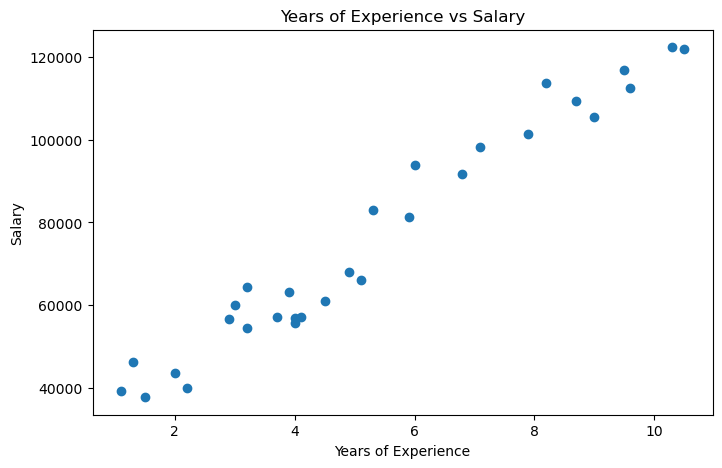

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["YearsExperience"], df["Salary"])
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

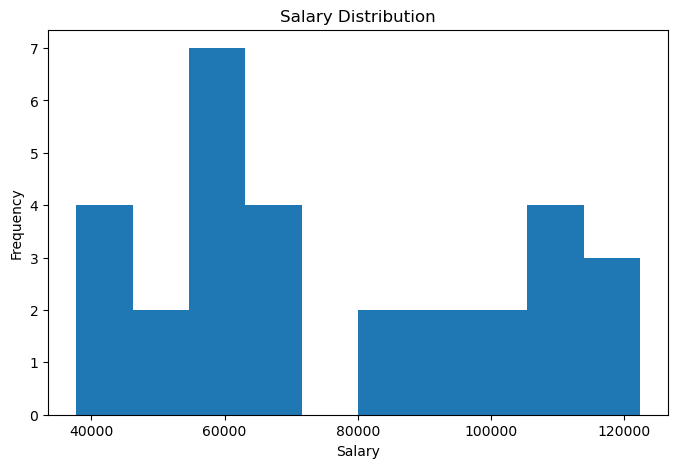

In [20]:
#histogram for salary
plt.figure(figsize=(8,5))
plt.hist(df["Salary"], bins=10)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

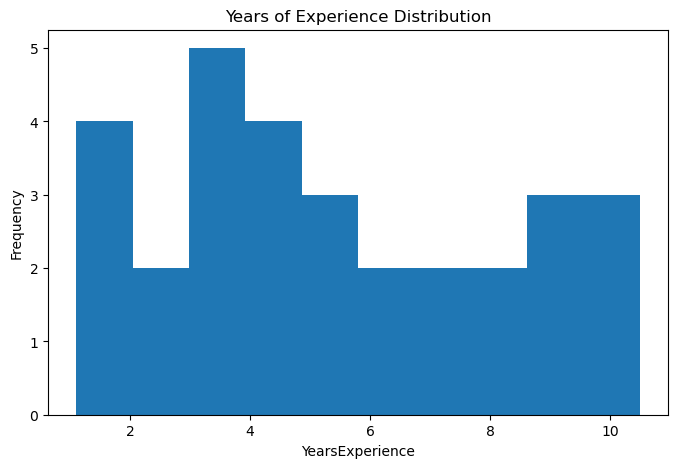

In [19]:
#Histogram of Years of Experience
plt.figure(figsize=(8,5))
plt.hist(df["YearsExperience"], bins=10)
plt.title("Years of Experience Distribution")
plt.xlabel("YearsExperience")
plt.ylabel("Frequency")
plt.show()

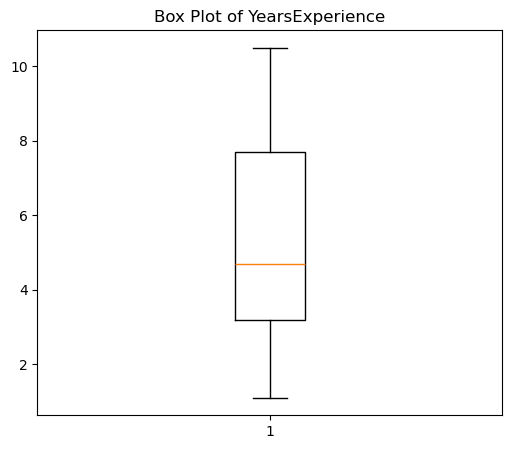

In [21]:
plt.figure(figsize=(6,5))
plt.boxplot(df["YearsExperience"])
plt.title("Box Plot of YearsExperience")
plt.show()

In [22]:
#Split the Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24, 1)
X_test : (6, 1)
y_train: (24,)
y_test : (6,)


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
#Train the Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
print("Coefficient:", model.coef_)

Coefficient: [27151.53742583]


In [28]:
print("Intercept:", model.intercept_)

Intercept: 74207.625


In [29]:
#Make Predictions
y_pred = model.predict(X_test)
print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [30]:
#Compare Actual vs Predicted
import pandas as pd
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
comparison

,Actual,Predicted
0,112635.0,115790.210113
1,67938.0,71498.278095
2,113812.0,102596.868661
3,83088.0,75267.804224
4,64445.0,55477.792045
5,57189.0,60189.699707


In [31]:
from sklearn.metrics import r2_score

In [32]:
y_pred = model.predict(X_test)

In [33]:
r2 = r2_score(y_test, y_pred)

In [34]:
r2

0.9024461774180498

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df[["YearsExperience"]]
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)

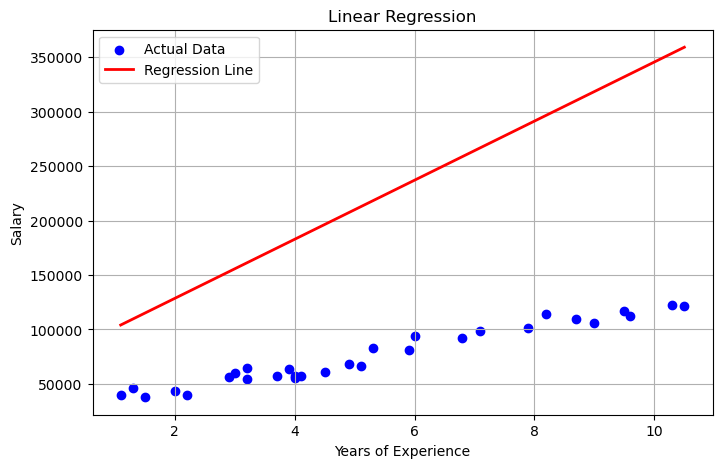

In [40]:
y_line = model.predict(X)
plt.figure(figsize=(8,5))
plt.scatter(df["YearsExperience"], df["Salary"], color="blue", label="Actual Data")
plt.plot(df["YearsExperience"], y_line, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [37]:
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("R² Score Percentage: {:.2f}%".format(r2 * 100))

Mean Absolute Error (MAE): 6286.453830757742
Mean Squared Error (MSE): 49830096.855908334
Root Mean Squared Error (RMSE): 7059.043621901506
R² Score: 0.9024461774180498
R² Score Percentage: 90.24%
